# Applying Learning Rate Scheduler to Upgraded Model with Data Augmentation (Scheduler Model) 

After using data augmentation on the previous improved CNN architecture, it may be a good time to apply another technique in order to seek faster convergence, better stability, and a higher final accuracy. This time, we will use a Learning Rate Scheduler, which is a tool that changes the learning rate of an optimizer during training. We start with a larger learning rate for faster exploration, and then lower it over time so the model can fine-tune its weights and settle into a better solution. For this model, we use Step Decay, which will reduce the learning rate by half every 10 epochs. Finally, this model will be referred to as the **Scheduler Model** from now on.

## Load Data

In [1]:
# Jupyter opens notebooks from the /waste-classification/notebooks directory, so we move to the project root.
%cd ..

/Users/rodrigomattos/Desktop/projects/waste-classification


In [2]:
from src.data import get_data, get_transform, get_transform_aug, get_datasets, get_dataloaders
import torch

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
transform = get_transform()
transform_aug = get_transform_aug()
dataset = get_data(transform)
dataset

Dataset ImageFolder
    Number of datapoints: 4817
    Root location: data/cnn_waste_classification
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [5]:
train_data, val_data, test_data = get_datasets(transform_aug, transform)

In [6]:
train_loader, val_loader, test_loader = get_dataloaders(train_data, val_data, test_data)

## Creating Model

In [7]:
from src.models import UpgradedConvolutionalNetwork

In [8]:
scheduler_model = UpgradedConvolutionalNetwork()
scheduler_model.load_state_dict(torch.load('models/04_scheduler_aug_sgd_momentum50.pth'))

<All keys matched successfully>

In [9]:
scheduler_model.to(device)

UpgradedConvolutionalNetwork(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=18432, out_features=90, bias=True)
  (fc2): Linear(in_features=90, out_features=9, bias=True)
)

## Evaluating Model

In [10]:
from src.evaluation import evaluate_model, create_confusion_matrix, inspecting_images

### - Validation Loss and Accuracy

In [11]:
loss, accuracy, all_labels, all_predictions = evaluate_model(scheduler_model, val_loader)

In [12]:
print(f"Validation Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Validation Loss: 1.3569
Accuracy: 50.62%


Given the validation loss of 1.3569 and accuracy of 50.62%, we can see a significant drop in both validation metrics with the Scheduler Model compared to the Upgraded Model. The Validation Loss increased by almost 0.3 (from 1.0630 to 1.3569), while the Validation Accuracy had a large decrease from 62.10% to 50.62%. We observe that the learning-rate decay did not improve generalization, while also worsening the validation metrics. Possible reasons for this could include early stagnation, loss of exploration due to the learning rate dropping too quickly, or even underfitting if the model was no longer able to make sufficiently large weight updates.

### - Confusion Matrix

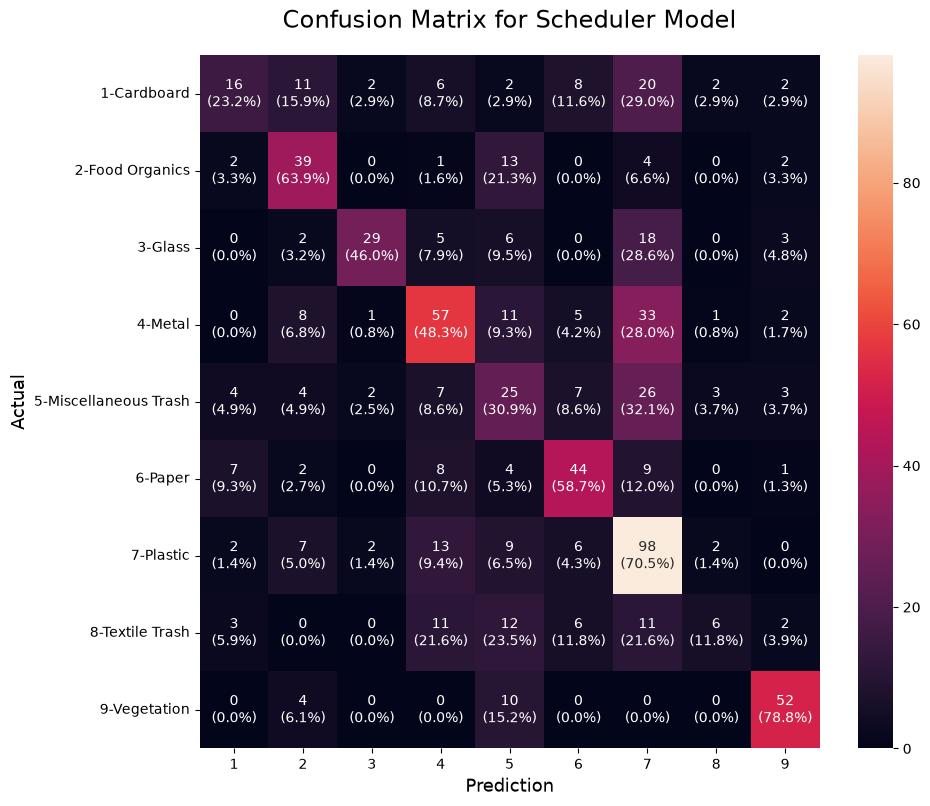

In [13]:
create_confusion_matrix(all_labels, all_predictions, dataset.classes, title="Confusion Matrix for Scheduler Model")

**Confusion Matrix Insights:**

. Basically all classes achieved lower accuracy with the Scheduler Model compared to the Upgraded Model.

. There were a few very poor-performing classes, including recurrent ones such as Miscellaneous Trash and Textile Trash, as well as an unprecedented one with Cardboard. This time, Textile Trash achieved only 11.8% accuracy, the lowest among all experiments.

. There was also a noticeable dispersion of predictions among the classes, which indicates that the model was quite uncertain across the different classes.

### - Inspecting misclassified images

Found 33 4-Metal → 7-Plastic


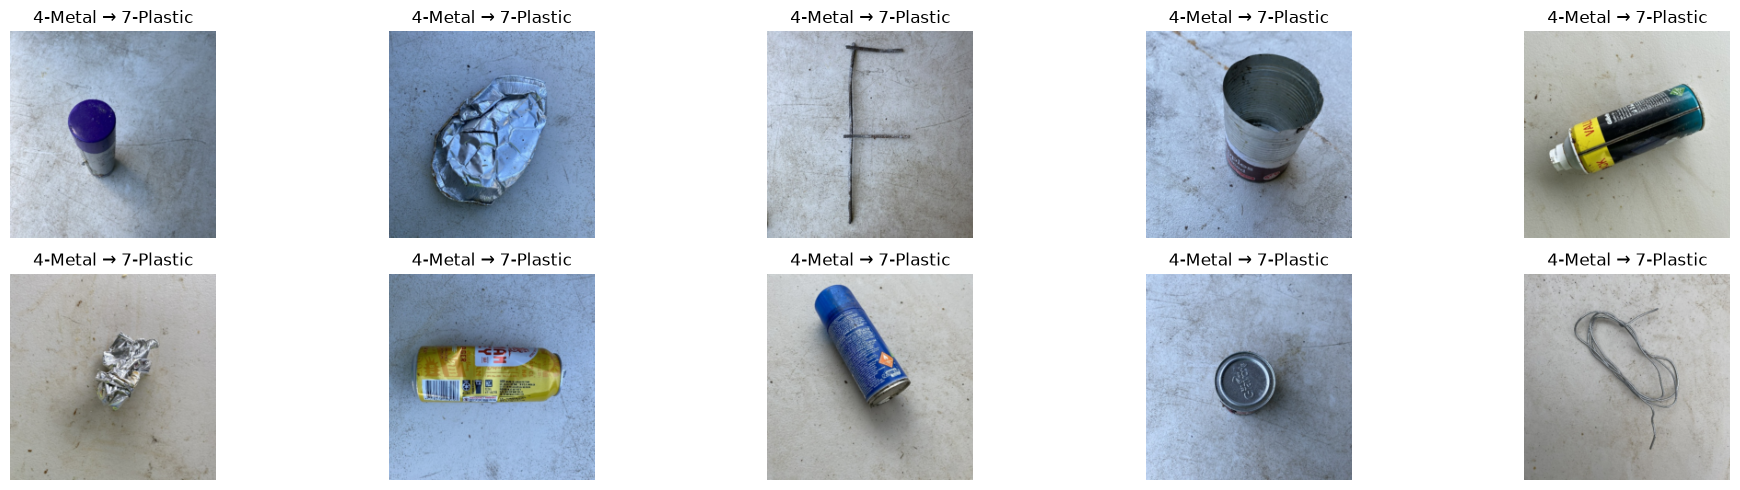

In [14]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "4-Metal", "7-Plastic") # 33 errors

Found 26 5-Miscellaneous Trash → 7-Plastic


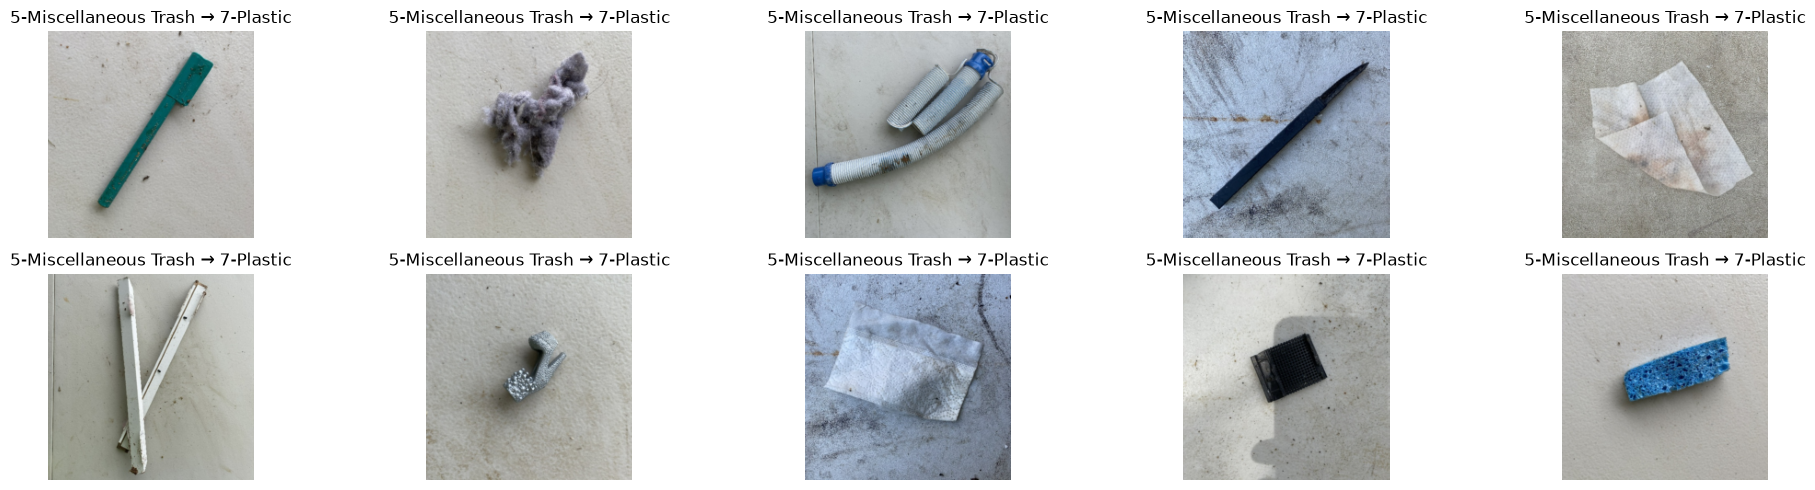

In [15]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "5-Miscellaneous Trash", "7-Plastic") # 26 errors

Found 12 8-Textile Trash → 5-Miscellaneous Trash


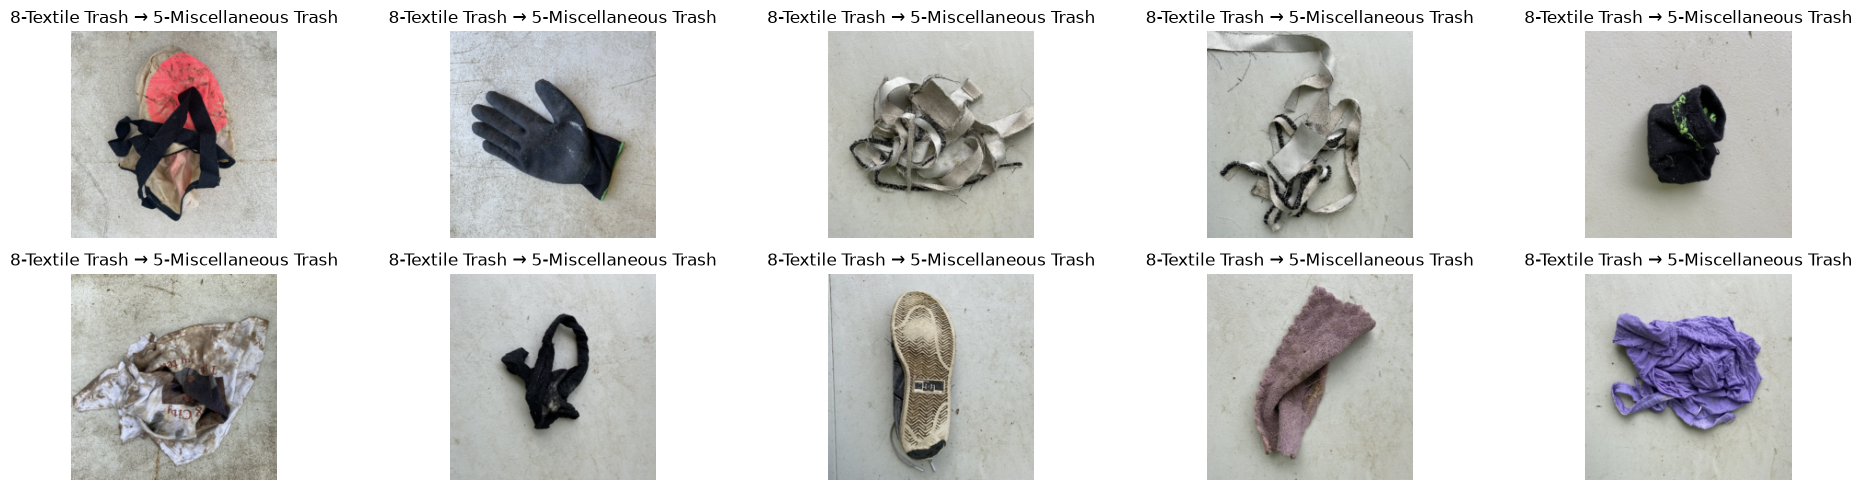

In [16]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "8-Textile Trash", "5-Miscellaneous Trash") # 12 errors

**Misclassified Images Insights:**  

. Again, many different types of objects were misclassified as Plastic, showing a tendency of the model to classify many objects as Plastic.

. The model misclassified a few clear Textile Trash objects as Miscellaneous Trash.